# 01 · Exploration des données — consommation électrique française

**Rassembler, nettoyer et explorer toutes les données nécessaires à la prévision de la consommation nationale d'électricité (horizon J+1, pas demi-horaire).**

| Source | Contenu | Accès |
|---|---|---|
| **RTE éCO2mix** (`eco2mix-national-cons-def`) | consommation historique consolidée/définitive, prévisions RTE J-1 / J | API Open Data RTE (sans clé) |
| **RTE éCO2mix** (`eco2mix-national-tr`) | consommation « temps réel » des derniers mois | API Open Data RTE (sans clé) |
| **Open-Meteo** (archive) | température, humidité, vent, nébulosité, rayonnement pour ~10 grandes villes | API gratuite (sans clé) |
| **Éducation nationale** | calendrier des vacances scolaires par zone | API data.education.gouv.fr |
| Package `holidays` | jours fériés français | local |

In [25]:
# %pip install pandas numpy matplotlib requests pyarrow statsmodels holidays

In [26]:
from pathlib import Path
import re, time, unicodedata, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.max_columns = 40
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW, PROC = ROOT / "data" / "raw", ROOT / "data" / "processed"
for p in (RAW, RAW / "weather", PROC):
    p.mkdir(parents=True, exist_ok=True)

# Paramètres
START = "2013-01-01"  # début de l'historique conservé
TZ = "Europe/Paris"
TODAY = pd.Timestamp.today().normalize()

# L'archive météo a quelques jours de retard
WEATHER_END = (TODAY - pd.Timedelta(days=6)).strftime("%Y-%m-%d")
FORCE_REFRESH = False # True = retélécharge tout

print("Racine du repo :", ROOT)

Racine du repo : c:\Users\baptm\Downloads\conso-rte


## 1. Consommation — RTE éCO2mix

Deux jeux de données se complètent :

- **`eco2mix-national-cons-def`** : données *consolidées* (comptages, disponibles quelques mois après) puis *définitives* (année suivante), au pas de 30 min. C'est la base d'entraînement.
- **`eco2mix-national-tr`** : données *temps réel* (télémesures + estimations) pour combler les derniers mois, au pas de 15 min.

Un jour donné n'est publié que sous **une seule nature** ; il faut donc garder trace de la provenance de chaque ligne.

In [27]:
ODRE_EXPORT = "https://opendata.reseaux-energies.fr/api/explore/v2.1/catalog/datasets/{}/exports/csv"
ODRE_PARAMS = {"timezone": "UTC", "use_labels": "false", "delimiter": ";"}

PATH_CONS_DEF = RAW / "eco2mix_national_cons_def.csv"
PATH_TR = RAW / "eco2mix_national_tr.csv"


def download(url, dest, params=None, force=False):
    # Télécharge `url` vers `dest` en streaming sauf si le fichier existe déjà
    if dest.exists() and not force:
        print(f"Déjà présent : {dest.name} ({dest.stat().st_size / 1e6:.1f} Mo)")
        return dest
    print(f"Téléchargement : {dest.name} ...")
    try:
        with requests.get(url, params=params, stream=True, timeout=600) as r:
            r.raise_for_status()
            with open(dest, "wb") as f:
                for chunk in r.iter_content(1 << 20):
                    f.write(chunk)
    except Exception as e:
        dest.unlink(missing_ok=True)
        raise RuntimeError(
            f"Échec du téléchargement de {dest.name} ({e}).\n"
            f"→ Télécharge le fichier manuellement et place-le ici : {dest}"
        ) from e
    print(f"   ok ({dest.stat().st_size / 1e6:.1f} Mo)")
    return dest


download(ODRE_EXPORT.format("eco2mix-national-cons-def"), PATH_CONS_DEF, ODRE_PARAMS, FORCE_REFRESH)
_ = download(ODRE_EXPORT.format("eco2mix-national-tr"), PATH_TR, ODRE_PARAMS, FORCE_REFRESH)

Déjà présent : eco2mix_national_cons_def.csv (84.9 Mo)
Déjà présent : eco2mix_national_tr.csv (1.8 Mo)


In [28]:
def norm_col(c):
    # 'Date - Heure' -> 'date_heure', 'Prévision J-1' -> 'prevision_j1', etc.
    c = unicodedata.normalize("NFKD", str(c)).encode("ascii", "ignore").decode().lower()
    c = re.sub(r"\(.*?\)", "", c)
    c = re.sub(r"[^a-z0-9]+", "_", c).strip("_")
    return c.replace("j_1", "j1")

def read_rte(path):
    df = pd.read_csv(path, sep=";", low_memory=False)
    if df.shape[1] == 1: # séparateur virgule
        df = pd.read_csv(path, sep=",", low_memory=False)
    df.columns = [norm_col(c) for c in df.columns]
    return df

raw_def, raw_tr = read_rte(PATH_CONS_DEF), read_rte(PATH_TR)
print("cons-def :", raw_def.shape, "| tr :", raw_tr.shape)
print("\nColonnes disponibles :\n", list(raw_def.columns))
raw_def.head(3)

cons-def : (508320, 37) | tr : (7872, 41)

Colonnes disponibles :
 ['perimetre', 'nature', 'date', 'heure', 'date_heure', 'consommation', 'prevision_j1', 'prevision_j', 'fioul', 'charbon', 'gaz', 'nucleaire', 'eolien', 'solaire', 'hydraulique', 'pompage', 'bioenergies', 'ech_physiques', 'taux_co2', 'ech_comm_angleterre', 'ech_comm_espagne', 'ech_comm_italie', 'ech_comm_suisse', 'ech_comm_allemagne_belgique', 'fioul_tac', 'fioul_cogen', 'fioul_autres', 'gaz_tac', 'gaz_cogen', 'gaz_ccg', 'gaz_autres', 'hydraulique_fil_eau_eclusee', 'hydraulique_lacs', 'hydraulique_step_turbinage', 'bioenergies_dechets', 'bioenergies_biomasse', 'bioenergies_biogaz']


,perimetre,nature,date,heure,date_heure,consommation,prevision_j1,prevision_j,fioul,charbon,gaz,nucleaire,eolien,solaire,hydraulique,pompage,bioenergies,ech_physiques,taux_co2,ech_comm_angleterre,ech_comm_espagne,ech_comm_italie,ech_comm_suisse,ech_comm_allemagne_belgique,fioul_tac,fioul_cogen,fioul_autres,gaz_tac,gaz_cogen,gaz_ccg,gaz_autres,hydraulique_fil_eau_eclusee,hydraulique_lacs,hydraulique_step_turbinage,bioenergies_dechets,bioenergies_biomasse,bioenergies_biogaz
0,France,Données définitives,2012-01-01,00:00,2011-12-31T23:00:00+00:00,58315.0,58200,58200,492.0,25.0,3816.0,52697.0,3588.0,0.0,7922.0,-1139.0,719.0,-9806.0,33.0,-1750.0,-1200.0,-862.0,-2625.0,-2940,NaN,NaN,NaN,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,France,Données définitives,2012-01-01,00:15,2011-12-31T23:15:00+00:00,NaN,57700,57550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,France,Données définitives,2012-01-01,00:30,2011-12-31T23:30:00+00:00,58315.0,57200,56900,492.0,25.0,3816.0,52697.0,3588.0,0.0,7922.0,-1139.0,719.0,-9806.0,33.0,-1750.0,-1200.0,-862.0,-2625.0,-2940,NaN,NaN,NaN,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
def clean_rte(df, source):
    df = df.copy()
    if "perimetre" in df.columns: # on ne garde que le périmètre France
        mask = df["perimetre"].astype(str).str.lower().eq("france")
        if mask.any():
            df = df[mask]
    if "date_heure" not in df.columns:
        raise KeyError(f"Colonne 'date_heure' introuvable. Colonnes : {list(df.columns)}")
    if "consommation" not in df.columns:
        raise KeyError(f"Colonne 'consommation' introuvable. Colonnes : {list(df.columns)}")
    df["date_heure"] = pd.to_datetime(df["date_heure"], utc=True)
    df["consommation"] = pd.to_numeric(df["consommation"], errors="coerce")
    df = df.dropna(subset=["consommation"])
    df["source"] = source
    return df.set_index("date_heure").sort_index()

# Les données consolidées/définitives sont prioritaires sur le temps réel
comb = pd.concat([clean_rte(raw_def, "cons_def"), clean_rte(raw_tr, "tr")])
comb = comb[~comb.index.duplicated(keep="first")].sort_index()

# Pas de 30 min : on garde les points à :00 et :30 (les points :15/:45 du temps réel sont écartés)
comb = comb[comb.index.minute % 30 == 0].loc[START:]

print(f"Période : {comb.index.min()} → {comb.index.max()}  ({len(comb):,} points)")
if "nature" in comb.columns:
    print("\nNature des données :\n", comb["nature"].value_counts())
print("\nPoints par année et par source :")
comb.groupby([comb.index.year, "source"]).size().unstack(fill_value=0)

Période : 2013-01-01 00:00:00+00:00 → 2026-09-19 12:30:00+00:00  (240,432 points)

Nature des données :
 nature
Données définitives    210358
Données consolidées     26204
Données temps réel       3870
Name: count, dtype: int64

Points par année et par source :


source,cons_def,tr
date_heure,,
2013,17518,0
2014,17518,0
2015,17518,0
2016,17566,0
2017,17518,0
2018,17518,0
2019,17518,0
2020,17566,0
2021,17518,0


### 1.1 Contrôle qualité : régularité, trous, valeurs aberrantes

In [30]:
full = pd.date_range(comb.index.min(), comb.index.max(), freq="30min")
missing = full.difference(comb.index)
print(f"Points attendus : {len(full):,} | présents : {len(comb):,} | manquants : {len(missing):,} "
      f"({len(missing) / len(full):.3%})")
print(f"Doublons d'index : {comb.index.duplicated().sum()}")

if len(missing):
    s = pd.Series(missing)
    grp = s.diff().ne(pd.Timedelta("30min")).cumsum().values
    gaps = s.groupby(grp).agg(debut="min", fin="max", n_points="size").sort_values("n_points", ascending=False)
    print("\nPlus longs trous :")
    display(gaps.head(10))

print("\nStatistiques de la consommation (MW) :")
display(comb["consommation"].describe().round(0).to_frame().T)
print("Valeurs <= 0 :", (comb["consommation"] <= 0).sum())

Points attendus : 240,458 | présents : 240,432 | manquants : 26 (0.011%)
Doublons d'index : 0

Plus longs trous :


,debut,fin,n_points
1,2013-10-27 00:00:00+00:00,2013-10-27 00:30:00+00:00,2
2,2014-10-26 00:00:00+00:00,2014-10-26 00:30:00+00:00,2
3,2015-10-25 00:00:00+00:00,2015-10-25 00:30:00+00:00,2
4,2016-10-30 00:00:00+00:00,2016-10-30 00:30:00+00:00,2
5,2017-10-29 00:00:00+00:00,2017-10-29 00:30:00+00:00,2
6,2018-10-28 00:00:00+00:00,2018-10-28 00:30:00+00:00,2
7,2019-10-27 00:00:00+00:00,2019-10-27 00:30:00+00:00,2
8,2020-10-25 00:00:00+00:00,2020-10-25 00:30:00+00:00,2
9,2021-10-31 00:00:00+00:00,2021-10-31 00:30:00+00:00,2
10,2022-10-30 00:00:00+00:00,2022-10-30 00:30:00+00:00,2



Statistiques de la consommation (MW) :


,count,mean,std,min,25%,50%,75%,max
consommation,240432.0,52655.0,11570.0,29124.0,43924.0,50859.0,60363.0,96272.0


Valeurs <= 0 : 0


Les trous correspondent au passage à l'heure d'hiver qui peut être compensé par le passage à l'heure en UTC

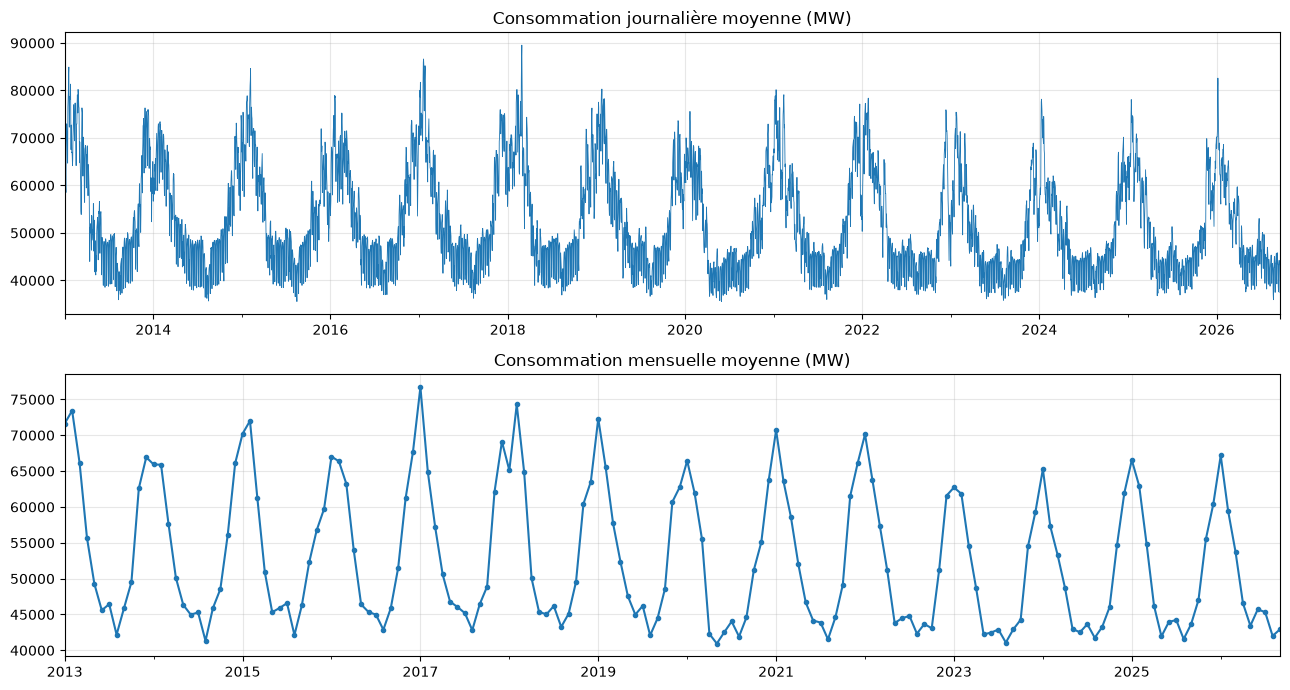

In [31]:
conso = comb.copy() # tz UTC, pas de 30 min
c = conso["consommation"]

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
c.resample("D").mean().plot(ax=axes[0], lw=0.6)
axes[0].set_title("Consommation journalière moyenne (MW)")
c.resample("MS").mean().plot(ax=axes[1], marker="o", ms=3)
axes[1].set_title("Consommation mensuelle moyenne (MW)")
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()

### 1.2 Tendance et ruptures de régime

À surveiller : baisse tendancielle (efficacité énergétique, autoconsommation solaire), **2020** (COVID), **2022-2023** (crise énergétique / sobriété). Ces ruptures conditionneront la fenêtre d'entraînement et la validation.

date_heure,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
moyenne_GW,56.2,52.8,54.0,54.7,54.7,54.3,53.7,50.8,53.5,51.4,49.7,50.1,50.7,49.8
n,17518,17518,17518,17566,17518,17518,17518,17566,17518,17518,17518,17566,17518,12554
complete,True,True,True,True,True,True,True,True,True,True,True,True,True,False


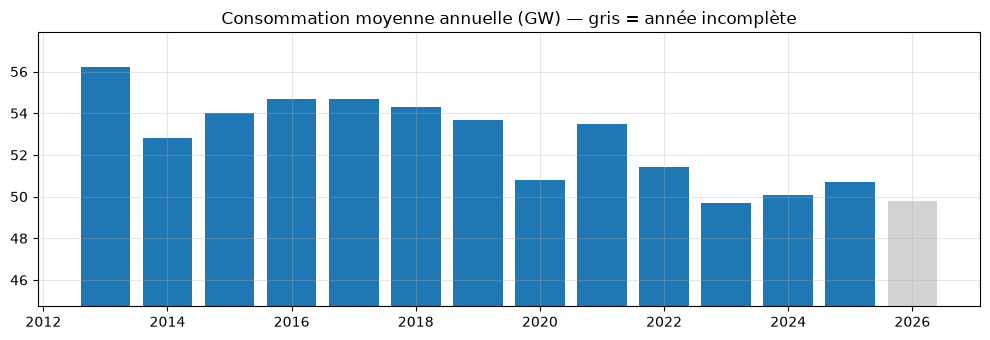

In [32]:
annual = c.groupby(c.index.year).agg(moyenne="mean", n="size")
annual["complete"] = annual["n"] >= 0.98 * 17520 # ~ année complète
annual["moyenne_GW"] = (annual["moyenne"] / 1000).round(1)

fig, ax = plt.subplots(figsize=(10, 3.5))
colors = ["tab:blue" if ok else "lightgray" for ok in annual["complete"]]
ax.bar(annual.index, annual["moyenne_GW"], color=colors)
ax.set_title("Consommation moyenne annuelle (GW) — gris = année incomplète")
ax.set_ylim(annual["moyenne_GW"].min() * 0.9, annual["moyenne_GW"].max() * 1.03)
plt.tight_layout()
annual[["moyenne_GW", "n", "complete"]].T

### 1.3 Saisonnalités : journalière, hebdomadaire, annuelle

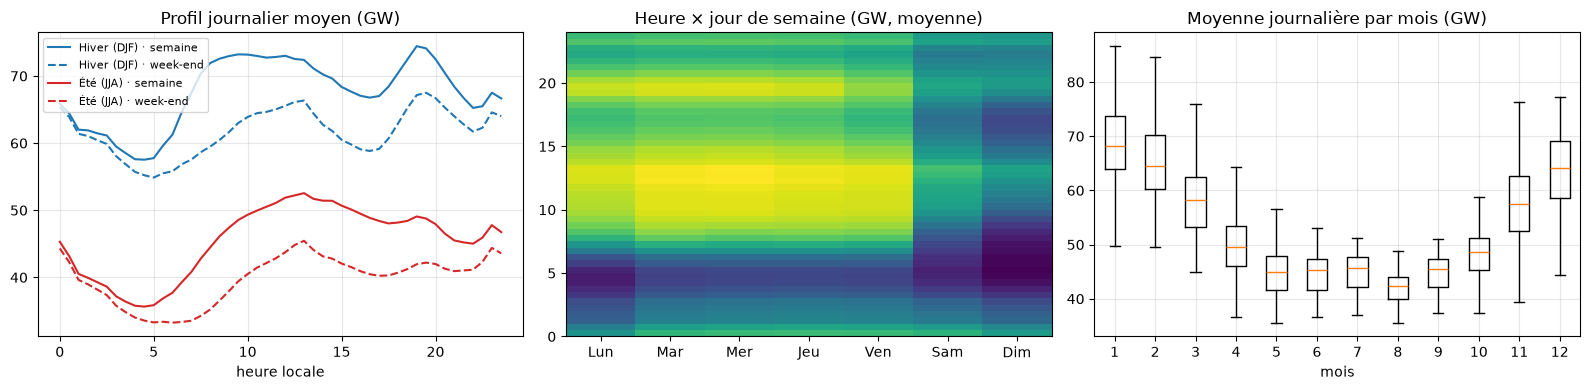

In [33]:
cl = c.tz_convert(TZ) # heure locale pour lire les profils
hh = cl.index.hour + cl.index.minute / 60
dow = cl.index.dayofweek
month = cl.index.month

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# profil journalier : hiver/été x semaine/week-end
for (sais, months), col in zip({"Hiver (DJF)": [12, 1, 2], "Été (JJA)": [6, 7, 8]}.items(), ["tab:blue", "tab:red"]):
    for label, dmask, ls in [("semaine", dow < 5, "-"), ("week-end", dow >= 5, "--")]:
        sel = cl[np.isin(month, months) & dmask]
        prof = sel.groupby(hh[np.isin(month, months) & dmask]).mean()
        axes[0].plot(prof.index, prof.values / 1000, color=col, ls=ls, label=f"{sais} · {label}")
axes[0].set_title("Profil journalier moyen (GW)"); axes[0].set_xlabel("heure locale"); axes[0].legend(fontsize=8)

# profil hebdomadaire
wk = cl.groupby([dow, hh]).mean().unstack(0)
axes[1].imshow(wk.values / 1000, aspect="auto", origin="lower", extent=[-.5, 6.5, 0, 24], cmap="viridis")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"])
axes[1].set_title("Heure × jour de semaine (GW, moyenne)"); axes[1].grid(False)

# saisonnalité annuelle : boîtes par mois sur les moyennes journalières
daily = cl.resample("D").mean()
axes[2].boxplot([daily[daily.index.month == m].values / 1000 for m in range(1, 13)], showfliers=False)
axes[2].set_xticklabels(range(1, 13))
axes[2].set_title("Moyenne journalière par mois (GW)"); axes[2].set_xlabel("mois")
plt.tight_layout()

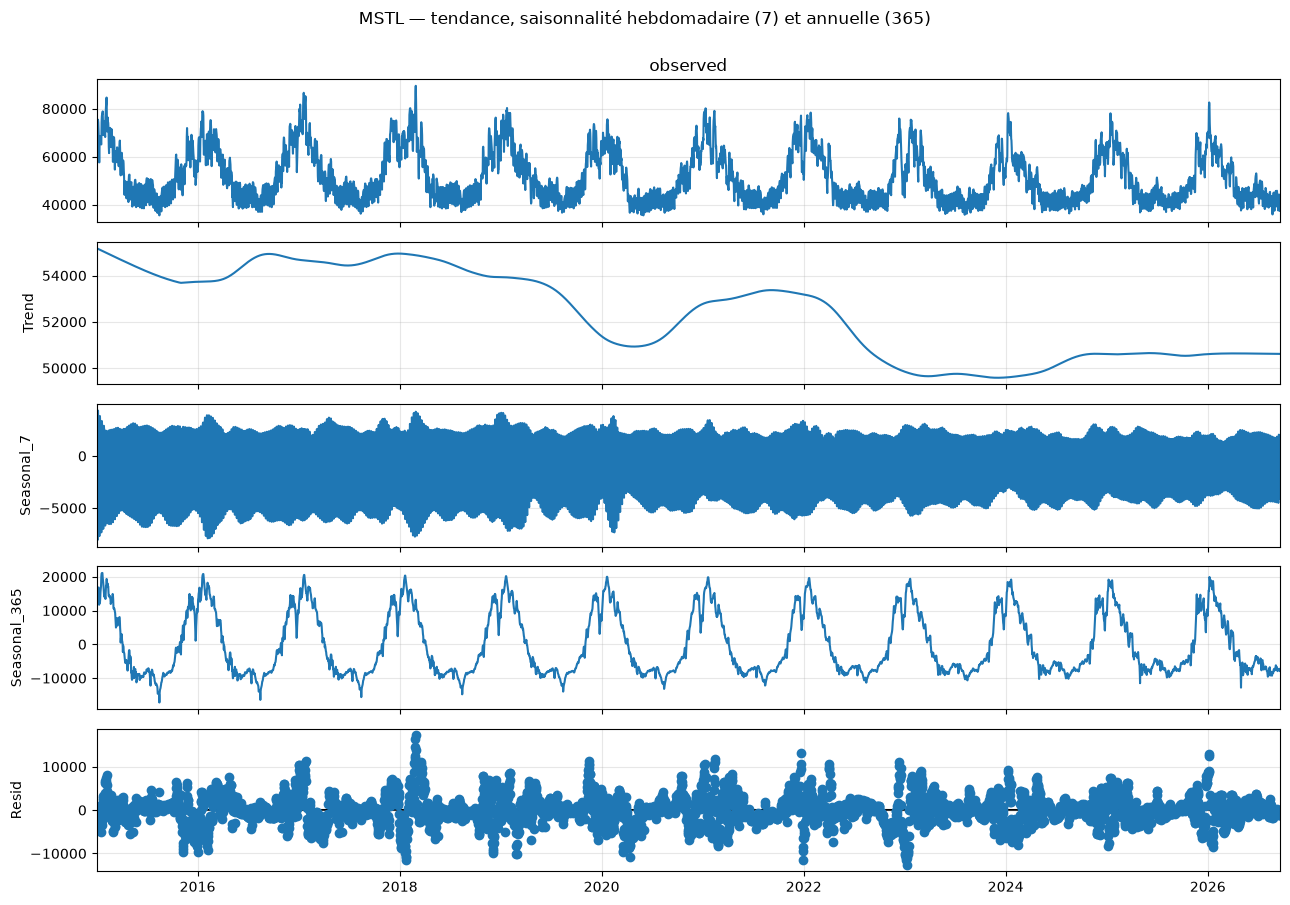

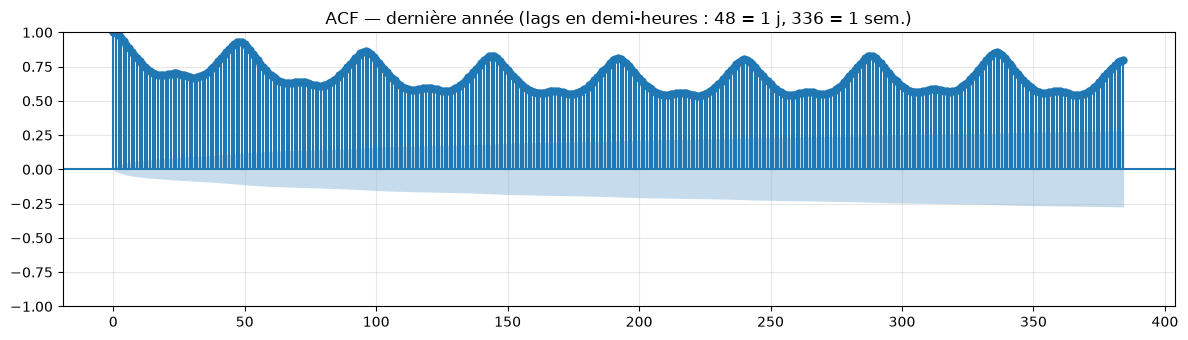

In [34]:
from statsmodels.tsa.seasonal import MSTL
from statsmodels.graphics.tsaplots import plot_acf

# Décomposition multi-saisonnière sur la série journalière (semaine + année)
daily_utc = c.resample("D").mean().interpolate().loc["2015":]
res = MSTL(daily_utc, periods=(7, 365)).fit()
fig = res.plot()
fig.set_size_inches(13, 9)
fig.suptitle("MSTL — tendance, saisonnalité hebdomadaire (7) et annuelle (365)", y=1.0)
plt.tight_layout()

# Autocorrélation au pas de 30 min : pics attendus à 48 (1 jour) et 336 (1 semaine)
fig, ax = plt.subplots(figsize=(12, 3.5))
plot_acf(c.iloc[-48 * 365:].interpolate(), lags=48 * 8, ax=ax)
ax.set_title("ACF — dernière année (lags en demi-heures : 48 = 1 j, 336 = 1 sem.)")
plt.tight_layout()

### 1.4 La prévision RTE : notre benchmark externe

Si les colonnes `prevision_j1` (prévision faite la veille) et `prevision_j` existent, elles servent de **référence à battre**

Colonnes de prévision RTE : ['prevision_j1', 'prevision_j']

Couverture (part de lignes renseignées) par année :


date_heure,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
prevision_j1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
prevision_j,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


,MAE (MW),RMSE (MW),MAPE (%),n
prevision_j1,957.11,1274.71,1.84,240432.0
prevision_j,762.32,1009.61,1.47,240291.0


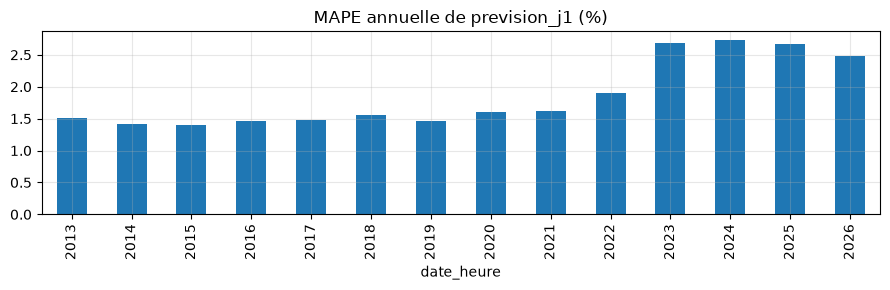

In [35]:
prev_cols = [x for x in conso.columns if x.startswith("prevision")]
print("Colonnes de prévision RTE :", prev_cols)

if prev_cols:
    cov = conso[prev_cols].notna().groupby(conso.index.year).mean().round(2)
    print("\nCouverture (part de lignes renseignées) par année :")
    display(cov.T)

    rows = {}
    for pc in prev_cols:
        sel = conso[["consommation", pc]].dropna()
        sel = sel[sel[pc] > 0]
        err = sel[pc] - sel["consommation"]
        rows[pc] = {
            "MAE (MW)": err.abs().mean(),
            "RMSE (MW)": np.sqrt((err ** 2).mean()),
            "MAPE (%)": (err.abs() / sel["consommation"]).mean() * 100,
            "n": len(sel),
        }
    display(pd.DataFrame(rows).T.round(2))

    pc = "prevision_j1" if "prevision_j1" in prev_cols else prev_cols[0]
    err = ((conso[pc] - conso["consommation"]) / conso["consommation"] * 100).dropna()
    err.groupby(err.index.year).apply(lambda s: s.abs().mean()).plot.bar(figsize=(9, 3), title=f"MAPE annuelle de {pc} (%)")
    plt.tight_layout()

## 2. Météo — Open-Meteo (archive)

On récupère, pour 10 grandes agglomérations, les variables horaires :
`temperature_2m`, `relative_humidity_2m`, `wind_speed_10m`, `cloud_cover`, `shortwave_radiation`.

> Ce sont des données *observées* (réanalyse ERA5). En production, on n'a que des *prévisions* météo, moins précises

In [36]:
# nom: (latitude, longitude, poids ~ population de l'agglomération en millions)
CITIES = {
    "Paris":      (48.8566,  2.3522, 10.9),
    "Lyon":       (45.7640,  4.8357,  2.3),
    "Marseille":  (43.2965,  5.3698,  1.9),
    "Toulouse":   (43.6047,  1.4442,  1.4),
    "Lille":      (50.6292,  3.0573,  1.2),
    "Bordeaux":   (44.8378, -0.5792,  1.3),
    "Nantes":     (47.2184, -1.5536,  1.0),
    "Strasbourg": (48.5734,  7.7521,  0.8),
    "Nice":       (43.7102,  7.2620,  1.0),
    "Rennes":     (48.1173, -1.6778,  0.75),
}
HOURLY = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "cloud_cover", "shortwave_radiation"]
ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"
PATH_METEO = RAW / "meteo_openmeteo.parquet"


def fetch_openmeteo(url, lat, lon, start, end, variables, max_retry=6):
    params = dict(latitude=lat, longitude=lon, start_date=start, end_date=end,
                  hourly=",".join(variables), timezone="UTC")
    for attempt in range(max_retry):
        r = requests.get(url, params=params, timeout=90)
        if r.status_code == 200:
            h = r.json()["hourly"]
            df = pd.DataFrame(h)
            df["time"] = pd.to_datetime(df["time"], utc=True)
            return df.set_index("time")
        if r.status_code == 429: # limite de débit
            wait = 30 * (attempt + 1)
            print(f"   429 — pause {wait}s")
            time.sleep(wait)
            continue
        r.raise_for_status()
    raise RuntimeError("Open-Meteo : trop de tentatives.")


def fetch_city_year(city, lat, lon, year):
    start = max(pd.Timestamp(START), pd.Timestamp(f"{year}-01-01"))
    end = min(pd.Timestamp(f"{year}-12-31"), pd.Timestamp(WEATHER_END))
    if start > end:
        return None
    cache = RAW / "weather" / f"{city}_{year}.parquet"
    if cache.exists():
        return pd.read_parquet(cache)
    df = fetch_openmeteo(ARCHIVE_URL, lat, lon, start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d"), HOURLY)
    if year < pd.Timestamp(WEATHER_END).year: # on ne met en cache que les années complètes
        df.to_parquet(cache)
    time.sleep(0.5)
    return df


if PATH_METEO.exists() and not FORCE_REFRESH:
    meteo = pd.read_parquet(PATH_METEO)
    print(f"Déjà présent : {PATH_METEO.name}")
else:
    frames = []
    for city, (lat, lon, _) in CITIES.items():
        print(f" - {city}")
        for year in range(int(START[:4]), int(WEATHER_END[:4]) + 1):
            d = fetch_city_year(city, lat, lon, year)
            if d is not None:
                frames.append(d.assign(city=city))
    meteo = pd.concat(frames).sort_index()
    meteo.to_parquet(PATH_METEO)

print(f"\n{meteo['city'].nunique()} villes | {meteo.index.min()} → {meteo.index.max()} | {len(meteo):,} lignes")
print("Valeurs manquantes (%) :")
display((meteo[HOURLY].isna().mean() * 100).round(2).to_frame("% NaN").T)

Déjà présent : meteo_openmeteo.parquet

10 villes | 2013-01-01 00:00:00+00:00 → 2026-09-13 23:00:00+00:00 | 1,200,960 lignes
Valeurs manquantes (%) :


,temperature_2m,relative_humidity_2m,wind_speed_10m,cloud_cover,shortwave_radiation
% NaN,0.0,0.0,0.0,0.0,0.0


Corrélation entre villes (température horaire) — min : 0.853


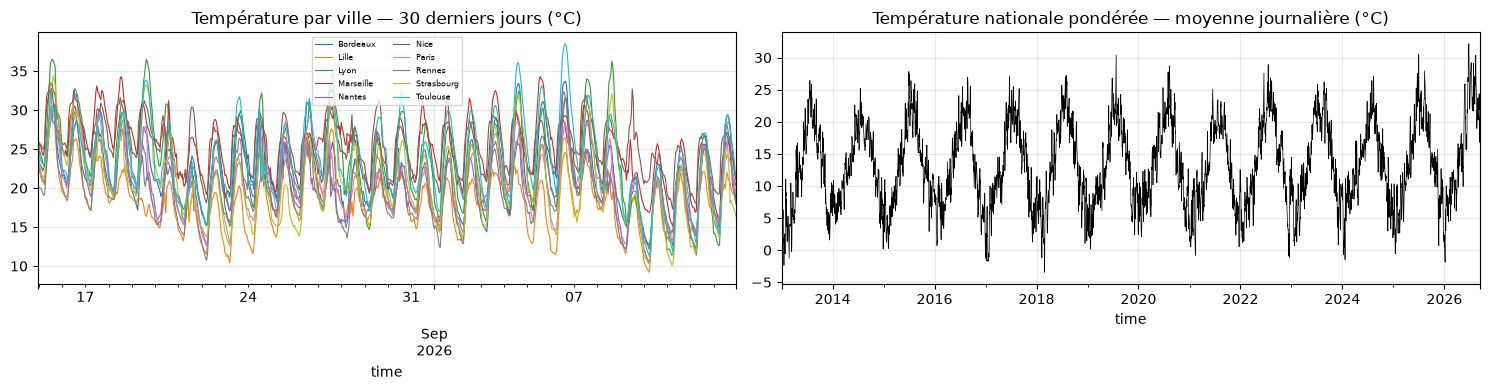

In [37]:
weights = pd.Series({k: v[2] for k, v in CITIES.items()})


def weighted_national(m):
    m = m.copy()
    w = m.pop("city").map(weights)
    valid = m[HOURLY].notna().mul(w, axis=0) # poids ignoré quand la valeur est NaN
    num = m[HOURLY].fillna(0).mul(w, axis=0).groupby(level=0).sum()
    den = valid.groupby(level=0).sum()
    return (num / den).sort_index()


nat = weighted_national(meteo)
nat.columns = ["temp_nat", "hum_nat", "wind_nat", "cloud_nat", "rad_nat"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
tc = meteo.pivot_table(index=meteo.index, columns="city", values="temperature_2m")
tc.loc[tc.index >= tc.index.max() - pd.Timedelta(days=30)].plot(ax=axes[0], lw=0.8, legend=True)
axes[0].legend(fontsize=6, ncol=2); axes[0].set_title("Température par ville — 30 derniers jours (°C)")
nat["temp_nat"].resample("D").mean().plot(ax=axes[1], lw=0.5, color="k")
axes[1].set_title("Température nationale pondérée — moyenne journalière (°C)")
plt.tight_layout()

print("Corrélation entre villes (température horaire) — min :", tc.corr().values.min().round(3))

### 2.3 Observé vs prévu : mesurer l'écart

Pour évaluer honnêtement un modèle J+1, il faut idéalement le nourrir avec des **prévisions météo passées** et non des observations. Open-Meteo propose une API de *prévisions historiques* (couverture plus courte, à partir de 2022 environ). Cette cellule compare, pour Paris, la température prévue à la température observée. Elle est désactivée par défaut.

In [38]:
CHECK_FORECAST_WEATHER = True # passer à True pour tester
HIST_FORECAST_URL = "https://historical-forecast-api.open-meteo.com/v1/forecast"

if CHECK_FORECAST_WEATHER:
    try:
        lat, lon, _ = CITIES["Paris"]
        f_start = "2023-01-01"
        f_end = min(pd.Timestamp(WEATHER_END), pd.Timestamp("2024-12-31")).strftime("%Y-%m-%d")
        fc = fetch_openmeteo(HIST_FORECAST_URL, lat, lon, f_start, f_end, ["temperature_2m"])
        obs = meteo.loc[meteo["city"] == "Paris", "temperature_2m"]
        cmp_ = pd.concat([obs.rename("observee"), fc["temperature_2m"].rename("prevue")], axis=1).dropna()
        err = cmp_["prevue"] - cmp_["observee"]
        print(f"Paris {f_start} → {f_end} : MAE = {err.abs().mean():.2f} °C | biais = {err.mean():+.2f} °C | n = {len(cmp_):,}")
    except Exception as e:
        print("API de prévisions historiques indisponible :", e)
else:
    print("Section désactivée (CHECK_FORECAST_WEATHER = False).")

Paris 2023-01-01 → 2024-12-31 : MAE = 1.02 °C | biais = +0.80 °C | n = 17,544


## 3. Calendrier : jours fériés et vacances scolaires

- **Jours fériés** : package `holidays`.
- **Ponts** : lundi si le mardi est férié, vendredi si le jeudi est férié.
- **Vacances scolaires** par zone A/B/C : jeu de données `fr-en-calendrier-scolaire` (Éducation nationale). Il ne couvre qu'une partie de l'historique : avant sa première date, les indicateurs restent `NaN`.

In [39]:
import holidays

SCHOOL_URL = "https://data.education.gouv.fr/api/explore/v2.1/catalog/datasets/fr-en-calendrier-scolaire/exports/csv"
PATH_SCHOOL = RAW / "calendrier_scolaire.csv"
download(SCHOOL_URL, PATH_SCHOOL, {"delimiter": ";"}, FORCE_REFRESH)

sch = pd.read_csv(PATH_SCHOOL, sep=";")
if sch.shape[1] == 1:
    sch = pd.read_csv(PATH_SCHOOL, sep=",")
sch.columns = [norm_col(x) for x in sch.columns]
print("Colonnes :", list(sch.columns))

sch = sch[sch["zones"].isin(["Zone A", "Zone B", "Zone C"])]
if "population" in sch.columns:
    sch = sch[~sch["population"].astype(str).str.contains("Enseignant", case=False)]
sch = sch[sch["description"].astype(str).str.contains("Vacances", case=False)]
sch = sch.drop_duplicates(["description", "zones", "start_date", "end_date"])
sch["start_date"] = pd.to_datetime(sch["start_date"], utc=True)
sch["end_date"] = pd.to_datetime(sch["end_date"], utc=True)
print(f"{len(sch)} périodes de vacances | {sch['start_date'].min().date()} → {sch['end_date'].max().date()}")
sch.sort_values("start_date").tail(6)

Déjà présent : calendrier_scolaire.csv (0.3 Mo)
Colonnes : ['description', 'population', 'start_date', 'end_date', 'location', 'zones', 'annee_scolaire']
165 périodes de vacances | 2017-10-20 → 2028-07-03


,description,population,start_date,end_date,location,zones,annee_scolaire
82,Vacances de Printemps,-,2028-04-07 22:00:00+00:00,2028-04-23 22:00:00+00:00,Aix-Marseille,Zone B,2027-2028
77,Vacances de Printemps,-,2028-04-14 22:00:00+00:00,2028-05-01 22:00:00+00:00,Toulouse,Zone C,2027-2028
69,Vacances de Printemps,-,2028-04-21 22:00:00+00:00,2028-05-08 22:00:00+00:00,Clermont-Ferrand,Zone A,2027-2028
30,Début des Vacances d'Été,-,2028-07-03 22:00:00+00:00,2028-07-03 22:00:00+00:00,Créteil,Zone C,2027-2028
23,Début des Vacances d'Été,-,2028-07-03 22:00:00+00:00,2028-07-03 22:00:00+00:00,Rennes,Zone B,2027-2028
19,Début des Vacances d'Été,-,2028-07-03 22:00:00+00:00,2028-07-03 22:00:00+00:00,Bordeaux,Zone A,2027-2028


In [40]:
days = pd.date_range(START, TODAY + pd.Timedelta(days=365), freq="D")

fr_h = holidays.country_holidays("FR", years=range(days[0].year, days[-1].year + 1))
cal = pd.DataFrame(index=days)
cal["is_holiday"] = [d.date() in fr_h for d in days]
cal["holiday_name"] = [fr_h.get(d.date()) for d in days]
dw = cal.index.dayofweek
cal["is_bridge"] = ((dw == 0) & cal["is_holiday"].shift(-1, fill_value=False)) | \
                   ((dw == 4) & cal["is_holiday"].shift(1, fill_value=False))

# Vacances scolaires : [début, fin[ en dates locales
for z in "ABC":
    cal[f"vac_{z}"] = 0.0
for _, r in sch.iterrows():
    s = r["start_date"].tz_convert(TZ).tz_localize(None).normalize()
    e = r["end_date"].tz_convert(TZ).tz_localize(None).normalize()
    cal.loc[(cal.index >= s) & (cal.index < e), f"vac_{r['zones'][-1]}"] = 1.0
cover_start = sch["start_date"].min().tz_convert(TZ).tz_localize(None).normalize()
cal.loc[cal.index < cover_start, ["vac_A", "vac_B", "vac_C"]] = np.nan          # hors couverture
cal["n_zones_vac"] = cal[["vac_A", "vac_B", "vac_C"]].sum(axis=1, min_count=3)

print(f"Vacances scolaires renseignées à partir du {cover_start.date()}")
print(f"Jours fériés : {cal['is_holiday'].sum()} | ponts : {cal['is_bridge'].sum()}")
cal.loc[TODAY:TODAY + pd.Timedelta(days=60)].query("is_holiday or n_zones_vac > 0").head(8)

Vacances scolaires renseignées à partir du 2017-10-21
Jours fériés : 162 | ponts : 43


,is_holiday,holiday_name,is_bridge,vac_A,vac_B,vac_C,n_zones_vac
2026-10-17,False,NaN,False,1.0,1.0,1.0,3.0
2026-10-18,False,NaN,False,1.0,1.0,1.0,3.0
2026-10-19,False,NaN,False,1.0,1.0,1.0,3.0
2026-10-20,False,NaN,False,1.0,1.0,1.0,3.0
2026-10-21,False,NaN,False,1.0,1.0,1.0,3.0
2026-10-22,False,NaN,False,1.0,1.0,1.0,3.0
2026-10-23,False,NaN,False,1.0,1.0,1.0,3.0
2026-10-24,False,NaN,False,1.0,1.0,1.0,3.0


In [41]:
from vacances_scolaires_france import SchoolHolidayDates

shd = SchoolHolidayDates()
pkg = pd.DataFrame(
    {f"vac_{z}": [float(shd.is_holiday_for_zone(d.date(), z)) for d in cal.index] for z in "ABC"},
    index=cal.index,
)

# 1) Contrôle de cohérence sur la période commune avec le jeu de l'Éducation nationale
overlap = (cal.index >= cover_start) & (cal.index <= TODAY)
for z in "ABC":
    ok = (pkg.loc[overlap, f"vac_{z}"] == cal.loc[overlap, f"vac_{z}"]).mean()
    print(f"Zone {z} : accord sur la période commune = {ok:.1%}")

# 2) Complément de l'historique avant la couverture de l'Éducation nationale
old = cal.index < cover_start
for z in "ABC":
    cal.loc[old, f"vac_{z}"] = pkg.loc[old, f"vac_{z}"]
cal["n_zones_vac"] = cal[["vac_A", "vac_B", "vac_C"]].sum(axis=1, min_count=3)
print(f"Vacances renseignées depuis {cal.index[cal['n_zones_vac'].notna()].min().date()} "
      f"| NaN restants : {cal['n_zones_vac'].isna().sum()}")

Zone A : accord sur la période commune = 99.4%
Zone B : accord sur la période commune = 98.6%
Zone C : accord sur la période commune = 99.0%
Vacances renseignées depuis 2013-01-01 | NaN restants : 0


## 4. Relations entre variables

### 4.1 Thermosensibilité : le graphique clé

En France, le chauffage électrique rend la consommation très sensible au froid (relation en « J »/« V » : forte pente en hiver, effet plus faible de la climatisation en été). On travaille sur des moyennes journalières en heure locale.

Pente de la consommation quand T < 12 °C (MW par °C, jours ouvrés) :


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
MW/°C,-2098.0,-2172.0,-2251.0,-1918.0,-2335.0,-1857.0,-2278.0,-1990.0,-2288.0,-2050.0,-2146.0,-1902.0,-2044.0,-2283.0


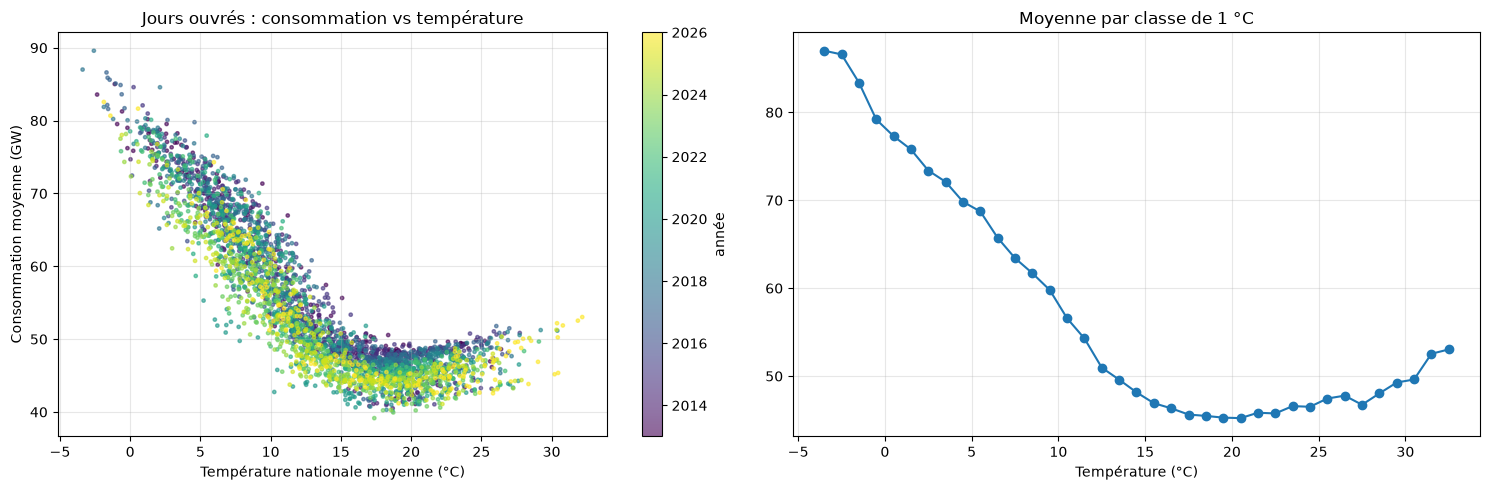

In [42]:
cd = conso["consommation"].tz_convert(TZ).resample("D").mean()
tj = nat["temp_nat"].tz_convert(TZ).resample("D").agg(["mean", "min", "max"])
tj.columns = ["t_mean", "t_min", "t_max"]

dj = pd.concat([cd.rename("conso"), tj], axis=1).dropna()
dj.index = dj.index.tz_localize(None)
dj = dj.join(cal[["is_holiday", "is_bridge"]])
dj["dow"] = dj.index.dayofweek
dj["year"] = dj.index.year
ok = dj[(dj["dow"] < 5) & (~dj["is_holiday"]) & (~dj["is_bridge"])] # jours ouvrés « normaux »

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sc = axes[0].scatter(ok["t_mean"], ok["conso"] / 1000, c=ok["year"], s=6, cmap="viridis", alpha=0.6)
plt.colorbar(sc, ax=axes[0], label="année")
axes[0].set_xlabel("Température nationale moyenne (°C)"); axes[0].set_ylabel("Consommation moyenne (GW)")
axes[0].set_title("Jours ouvrés : consommation vs température")

bins = np.arange(np.floor(ok["t_mean"].min()), np.ceil(ok["t_mean"].max()) + 1, 1)
binned = ok.groupby(pd.cut(ok["t_mean"], bins))["conso"].mean() / 1000
axes[1].plot([b.mid for b in binned.index], binned.values, "o-")
axes[1].set_xlabel("Température (°C)"); axes[1].set_title("Moyenne par classe de 1 °C")

# Pente hivernale (MW par °C) par année, sur les jours froids
cold = ok[ok["t_mean"] < 12]
slopes = cold.groupby("year").apply(lambda g: np.polyfit(g["t_mean"], g["conso"], 1)[0] if len(g) > 20 else np.nan)
plt.tight_layout()
print("Pente de la consommation quand T < 12 °C (MW par °C, jours ouvrés) :")
display(slopes.round(0).to_frame("MW/°C").T)

### 4.2 Quelle température utiliser ? (lissage et retards)

L'inertie thermique des bâtiments fait que la consommation dépend aussi de la température des jours précédents. On compare, en hiver, la corrélation de la consommation (normalisée par sa moyenne mobile annuelle, pour neutraliser la tendance) avec plusieurs versions de la température.

In [43]:
d = dj.copy()
d["conso_norm"] = d["conso"] / d["conso"].rolling(365, center=True, min_periods=180).mean()
d["t_lag1"] = d["t_mean"].shift(1)
d["t_roll3"] = d["t_mean"].rolling(3).mean()
d["t_ewm"] = d["t_mean"].ewm(alpha=0.5).mean()

winter = d[(d.index.month.isin([12, 1, 2])) & (d["dow"] < 5) & (~d["is_holiday"]) & (~d["is_bridge"])].dropna()
cols = ["t_mean", "t_min", "t_max", "t_lag1", "t_roll3", "t_ewm"]
print(f"Corrélation avec la conso normalisée — hiver, jours ouvrés (n = {len(winter)})")
winter[cols].corrwith(winter["conso_norm"]).round(3).sort_values().to_frame("corr").T

Corrélation avec la conso normalisée — hiver, jours ouvrés (n = 854)


,t_ewm,t_roll3,t_lag1,t_mean,t_max,t_min
corr,-0.908,-0.895,-0.866,-0.86,-0.832,-0.821


### 4.3 Effet du type de jour

Écart de la consommation journalière à sa médiane mobile de 29 jours, selon le type de jour.

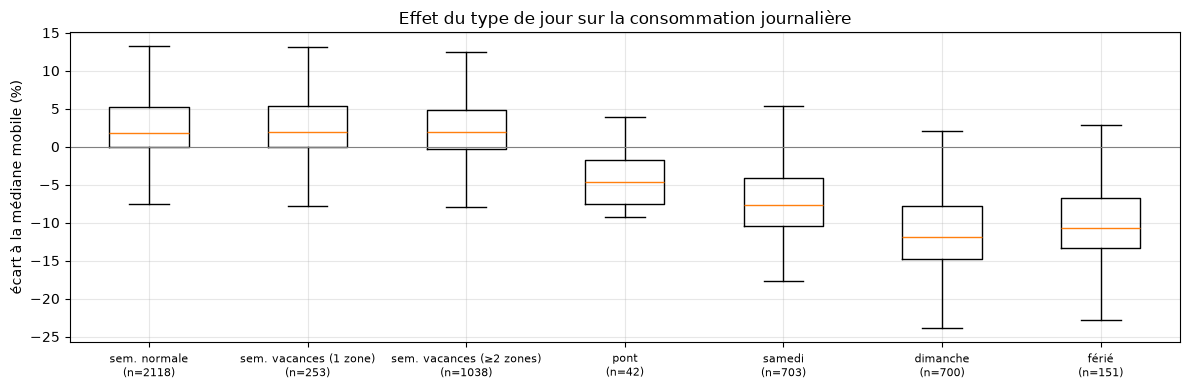

In [44]:
d = dj.join(cal[["vac_A", "vac_B", "vac_C", "n_zones_vac"]])
d["rel"] = d["conso"] / d["conso"].rolling(29, center=True, min_periods=15).median() - 1

d["type_jour"] = np.select(
    [d["is_holiday"], d["is_bridge"], d["dow"] == 6, d["dow"] == 5, d["n_zones_vac"] >= 2, d["n_zones_vac"] > 0],
    ["férié", "pont", "dimanche", "samedi", "sem. vacances (≥2 zones)", "sem. vacances (1 zone)"],
    default="sem. normale",
)
order = ["sem. normale", "sem. vacances (1 zone)", "sem. vacances (≥2 zones)", "pont", "samedi", "dimanche", "férié"]
groups = [d.loc[d["type_jour"] == t, "rel"].dropna() * 100 for t in order]

fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot(groups, showfliers=False)
ax.set_xticklabels([f"{t}\n(n={len(g)})" for t, g in zip(order, groups)], fontsize=8)
ax.axhline(0, color="gray", lw=0.8)
ax.set_ylabel("écart à la médiane mobile (%)"); ax.set_title("Effet du type de jour sur la consommation journalière")
plt.tight_layout()

## 5. Assemblage du jeu de données final

Un seul DataFrame au pas de 30 min (index UTC) contenant :

- la cible `conso`, sa provenance `source`/`nature`, les prévisions RTE si disponibles ;
- la météo nationale (interpolée à 30 min) ;
- les variables calendaires calculées **en heure locale**.

Les petits trous de consommation (≤ 4 pas = 2 h) sont interpolés et signalés par `conso_interpolee`. Les trous plus longs restent `NaN` : à traiter explicitement au moment de la modélisation.

In [45]:
idx = pd.date_range(conso.index.min(), conso.index.max(), freq="30min")
ds = pd.DataFrame(index=idx)
ds.index.name = "date_heure"

ds["conso"] = conso["consommation"].reindex(idx)
ds["conso_interpolee"] = ds["conso"].isna()
ds["conso"] = ds["conso"].interpolate(limit=4, limit_area="inside")
ds["conso_interpolee"] &= ds["conso"].notna()
ds["source"] = conso["source"].reindex(idx)
if "nature" in conso.columns:
    ds["nature"] = conso["nature"].reindex(idx)
for pc in prev_cols:
    ds[pc] = conso[pc].reindex(idx)

# Météo : horaire -> 30 min par interpolation temporelle
nat30 = nat.resample("30min").interpolate(method="time")
ds = ds.join(nat30, how="left")

# Calendrier en heure locale
loc = ds.index.tz_convert(TZ)
ds["heure_locale"] = loc.hour + loc.minute / 60
ds["jour_semaine"] = loc.dayofweek
ds["mois"] = loc.month
ds["jour_annee"] = loc.dayofyear
date_loc = loc.tz_localize(None).normalize()
cal_cols = ["is_holiday", "is_bridge", "vac_A", "vac_B", "vac_C", "n_zones_vac"]
ds[cal_cols] = cal.reindex(date_loc)[cal_cols].values
ds["is_holiday"] = ds["is_holiday"].astype(bool)
ds["is_bridge"] = ds["is_bridge"].astype(bool)

print(f"{ds.shape[0]:,} lignes × {ds.shape[1]} colonnes | {ds.index.min()} → {ds.index.max()}")
ds.tail(3)

240,458 lignes × 21 colonnes | 2013-01-01 00:00:00+00:00 → 2026-09-19 12:30:00+00:00


,conso,conso_interpolee,source,nature,prevision_j1,prevision_j,temp_nat,hum_nat,wind_nat,cloud_nat,rad_nat,heure_locale,jour_semaine,mois,jour_annee,is_holiday,is_bridge,vac_A,vac_B,vac_C,n_zones_vac
date_heure,,,,,,,,,,,,,,,,,,,,,
2026-09-19 11:30:00+00:00,40949.0,False,tr,Données temps réel,41300.0,41300.0,NaN,NaN,NaN,NaN,NaN,13.5,5,9,262,False,False,0.0,0.0,0.0,0.0
2026-09-19 12:00:00+00:00,41173.0,False,tr,Données temps réel,40400.0,40500.0,NaN,NaN,NaN,NaN,NaN,14.0,5,9,262,False,False,0.0,0.0,0.0,0.0
2026-09-19 12:30:00+00:00,40956.0,False,tr,Données temps réel,41900.0,42000.0,NaN,NaN,NaN,NaN,NaN,14.5,5,9,262,False,False,0.0,0.0,0.0,0.0


In [46]:
report = pd.DataFrame({
    "premier": ds.apply(lambda s: s.first_valid_index()),
    "dernier": ds.apply(lambda s: s.last_valid_index()),
    "% NaN": (ds.isna().mean() * 100).round(2),
    "dtype": ds.dtypes.astype(str),
})
display(report)

ds.to_parquet(PROC / "dataset_30min.parquet")
print(f"\nSauvegardé : {PROC / 'dataset_30min.parquet'}")

,premier,dernier,% NaN,dtype
conso,2013-01-01 00:00:00+00:00,2026-09-19 12:30:00+00:00,0.00,float64
conso_interpolee,2013-01-01 00:00:00+00:00,2026-09-19 12:30:00+00:00,0.00,bool
source,2013-01-01 00:00:00+00:00,2026-09-19 12:30:00+00:00,0.01,str
nature,2013-01-01 00:00:00+00:00,2026-09-19 12:30:00+00:00,0.01,str
prevision_j1,2013-01-01 00:00:00+00:00,2026-09-19 12:30:00+00:00,0.01,float64
prevision_j,2013-01-01 00:00:00+00:00,2026-09-19 12:30:00+00:00,0.01,float64
temp_nat,2013-01-01 00:00:00+00:00,2026-09-13 23:00:00+00:00,0.11,float64
hum_nat,2013-01-01 00:00:00+00:00,2026-09-13 23:00:00+00:00,0.11,float64
wind_nat,2013-01-01 00:00:00+00:00,2026-09-13 23:00:00+00:00,0.11,float64
cloud_nat,2013-01-01 00:00:00+00:00,2026-09-13 23:00:00+00:00,0.11,float64



Sauvegardé : c:\Users\baptm\Downloads\conso-rte\data\processed\dataset_30min.parquet


## 6. Bilan et décisions pour la suite

### Constats et décisions

- **Trous.** Les 26 points manquants sont 13 années × 2 points, tous le dimanche du passage à l'heure d'hiver (00:00-00:30 UTC) : ce ne sont pas de vrais trous. Ils sont déjà interpolés et signalés (`conso_interpolee`). En revanche, la météo s'arrête au 13 septembre (retard de l'archive) : les derniers jours n'ont pas de température.
- **Nature des données.** D'après les effectifs, les définitives couvrent 2013-2024, les consolidées 2025 à mi-2026 (~18 mois) et le temps réel les ~80 derniers jours. **Le temps réel est exclu de l'évaluation** (il ne sert qu'à une démo « live »). Le test se fait sur les consolidées.
- **Ruptures de régime.** La tendance MSTL passe d'environ 55 GW (2015-2019) à environ 50 GW depuis 2023 (baisses en 2020 et 2022-2023). Sur le nuage consommation/température (4.1), tout le nuage descend avec les années : à température égale, plusieurs GW de moins (de l'ordre de 8 GW à 5 °C entre 2013-2016 et 2024-2026). La pente hivernale, elle, reste stable (−1,9 à −2,3 GW/°C, sans tendance) : c'est le **niveau** qui bouge, pas la sensibilité au froid.
  → Un modèle « calendrier + météo » seul serait biaisé. Il faut des variables qui portent le niveau courant (consommation retardée compatible avec l'heure d'émission, moyenne des 7 derniers jours) et/ou une pondération par récence. Confinement de mars-mai 2020 : à exclure de l'entraînement ou à signaler. Sobriété 2022-2023 : à garder (proche du régime de test). Depuis 2023 la tendance est stable, ce qui est favorable au test.
- **Température.** La corrélation hivernale classe : `t_ewm` (−0,91) > `t_roll3` (−0,90) > `t_lag1` (−0,87) > `t_mean` (−0,86) > `t_max` / `t_min` (~−0,82). La température **lissée** est nettement meilleure que la brute → moyenne exponentielle et moyenne sur 3 jours à intégrer. La remontée au-dessus de ~25 °C (climatisation) justifie des variables de type degrés-jours de chauffe **et** de froid.
- **Météo observée vs prévue (Paris, 2023-2024).** MAE ≈ 1,0 °C, biais +0,8 °C (le prévu est plus chaud que l'observé). À ~2 GW/°C, cela pèse autant que l'erreur de RTE elle-même. Nuances : Paris seul exagère l'écart national (les erreurs des villes se compensent en partie), et l'API renvoie des prévisions à court terme, pas de vraies prévisions J-1.
 Chaque modèle sera évalué en **deux modes** (météo observée / météo prévue) ; l'écart mesure le coût de l'incertitude météo.
- **Benchmark RTE.** La MAPE globale de `prevision_j1` (1,84 %) est trompeuse : ~1,5 % jusqu'en 2019, ~2,5-2,7 % depuis 2023. **Le chiffre à situer sur la période de test est ~2,5-2,7 %.** Cause inconnue (vraie dégradation ou changement de méthode) à diagnostiquer avec le biais signé par année et en comparant au naïf J-7. On utilise uniquement `prevision_j1` : `prevision_j` est mise à jour dans la journée et n'est pas comparable à un modèle J+1.
- **Vacances scolaires.** Couverture à partir du 21 octobre 2017 (35 % de NaN). L'effet national paraît faible (les semaines de vacances ressemblent aux semaines normales), alors que le pont (~−4,5 %), le samedi (~−7,5 %), le dimanche (~−12 %) et les fériés (~−11 %) ressortent nettement. Réserve : la comparaison se fait à la médiane mobile de 29 jours, donc confondue avec la saison. On **ne sacrifie pas** 4,8 ans de données pour cette variable ; les NaN sont acceptés ou remplacés par 0 selon le modèle.

### Protocole retenu

1. **Heure d'émission :** prévision émise le jour D à 10 h pour les 48 pas de D+1. Les baselines n'utilisent que des données ≤ fin de D−1 (conservateur, aucune fuite possible).
2. **Découpage :** réglage/ablation avec entraînement < 2023 et validation 2023-2024 ; test en *rolling origin* de janvier 2025 au dernier jour consolidé, avec réentraînement mensuel.
4. **Métriques :** MAE, RMSE, MAPE, biais, MASE (référence : naïf J-7), et erreur sur la pointe journalière.

### Questions ouvertes

- Pourquoi la MAPE de RTE J-1 double-t-elle à partir de 2023 ? (biais ? erreur commune à tous les modèles ?)
- L'écart observé/prévu de la température se confirme-t-il sur les autres villes et sur la température nationale ?
- Faut-il un indicateur « sobriété » (oct. 2022 - mars 2023) si les lags ne suffisent pas à absorber le niveau ?